<a href="https://colab.research.google.com/github/ashycoding/Deep-Learning-Labs/blob/main/DL_Lab6_attention_heatmap_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Session: Understanding Attention Heatmaps

## Goal
- Learn the core concept of attention
- Plot attention weights as a heatmap
- See which words connect most strongly with others

## Concept Overview
**Attention** is a way for a model to decide which parts of a text to focus on when reading it.

Imagine the sentence **"The quick brown fox"**. The word **"fox"** is closely connected to **"brown"** because it describes the animal.

In our attention grid:
- **Rows** are the current word we are looking at (**Query**)
- **Columns** are the other words we check for relevance (**Key**)
- Values show the connection strength

A **heatmap** colors these numbers so we can spot patterns easily.


## Step 1: Load Necessary Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Pick a Sentence

We start with a four-word sentence to keep the visual clear.

In [2]:
words = ["The", "quick", "brown", "fox"]
words

['The', 'quick', 'brown', 'fox']

## Step 3: Make an Example Matrix

We will create attention scores manually to show how they work.
Each row shows the focus one word places on everything else.

Notice that the numbers across each row add up to 1.

In [3]:
attention = np.array([
    [0.25, 0.25, 0.25, 0.25],
    [0.10, 0.40, 0.30, 0.20],
    [0.05, 0.15, 0.50, 0.30],
    [0.10, 0.10, 0.40, 0.40]
])

attention

array([[0.25, 0.25, 0.25, 0.25],
       [0.1 , 0.4 , 0.3 , 0.2 ],
       [0.05, 0.15, 0.5 , 0.3 ],
       [0.1 , 0.1 , 0.4 , 0.4 ]])

## Step 4: Verify Row Totals

This proves the scores in each row spread out to total exactly 1.0.

In [4]:
attention.sum(axis=1)

array([1., 1., 1., 1.])

## Step 5: Draw the Heatmap

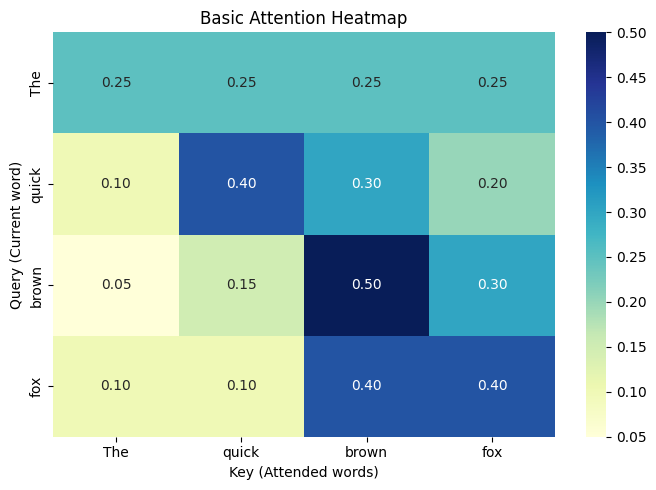

In [5]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    attention,
    xticklabels=words,
    yticklabels=words,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)
plt.title('Basic Attention Heatmap')
plt.xlabel('Key (Attended words)')
plt.ylabel('Query (Current word)')
plt.tight_layout()
plt.show()

## How to Read It

Analyze the colors in the grid:
- Darker shades mean stronger focus
- The top row is for the word **"The"**
- The bottom row is for the word **"fox"**

For instance:
- In the bottom row, **"fox"** has strong focus on **"brown"** and itself.
- In the top row, **"The"** looks equally at every word.


## Step 6: Find Peak Attention

This code loop prints out the strongest link for each word.

In [6]:
for i, query_word in enumerate(words):
    max_index = np.argmax(attention[i])
    print(f'Word "{query_word}" focuses most on "{words[max_index]}" (score {attention[i, max_index]:.2f})')

Word "The" focuses most on "The" (score 0.25)
Word "quick" focuses most on "quick" (score 0.40)
Word "brown" focuses most on "brown" (score 0.50)
Word "fox" focuses most on "brown" (score 0.40)
